# Анализ системы метрик приложения

**Автор**: Макковеева Елена<br>
**Дата**: 09.08.2025

## Цель и описание проекта 
Анализ системы метрик приложения Procrastinate Pro+, которое предоставляет пользователям доступ к развлекательному контенту: видео, подкастам и блогам.

К началу лета в приложении появился новый вид контента — спортивный. С его помощью менеджеры стремятся расширить аудиторию, добавив в неё пользователей, которые увлекаются спортом и здоровым образом жизни.

К запуску нового контента была скорректирована маркетинговая стратегия привлечения пользователей. Согласно бизнес-модели продукта, привлечение должно окупиться за **первые 28 дней (4 недели)**.

## Задачи
- провести анализ юнит-экономики продукта в динамике за первые 28 дней;
- разобраться в причинах стагнации выручки;
- определить, какие источники привлечения приносят прибыль, а какие не выходят на уровень окупаемости;
- дать рекомендации отделу маркетинга.


## Описание данных

Предоставлены данные о посещениях приложения, покупках и расходах на маркетинг.
Данные собраны в трёх датасетах.

1. Датасет `ppro_visits.csv` — информация о посещениях приложения пользователями, которые зарегистрировались с 1 апреля 2024 года по 30 ноября 2024 года:
    - `user_id` — уникальный идентификатор пользователя;
    - `region` — страна пользователя;
    - `device` — категория устройства пользователя;
    - `channel` — идентификатор рекламного источника, из которого пришёл пользователь;
    - `session_start` — дата и время начала сессии;
    - `session_end` — дата и время окончания сессии.

2. Датасет `ppro_orders.csv` — информация о покупках:
    - `user_id` — уникальный идентификатор пользователя, который сделал покупку;
    - `event_dt` — дата и время покупки;
    - `revenue` — выручка.

3. Датасет `ppro_costs.csv` — информация о затратах на маркетинг:
    - `dt` — дата
    - `channel` — идентификатор рекламного источника;
    - `costs` — затраты на этот рекламный источник в этот день.
    
## План проекта
- Загрузить и предобработать данные.
- Подготовить данные для когортного анализа.
- Рассчитать и проанализировать метрики вовлечённости в продукт.
- Рассчитать и проанализировать финансовые метрики CAC, LTV и ROI за первые 28 дней с момента привлечения.
- Исследовать метрики в разрезе источника привлечения.
- Рассчитать период окупаемости маркетинговых вложений.
- Сформулировать выводы и рекомендации.


## Загрузка и предобработка данных

In [1]:
#Импортируем библиотеки для обработки данных и визуализации
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

In [2]:
#Загружаем датасет с посещениями приложения
visits = pd.read_csv('https://code.s3.yandex.net/datasets/ppro_visits.csv', parse_dates=['session_start','session_end'])
visits.head()

,user_id,region,device,channel,session_start,session_end
0,631105188566,India,desktop,MediaTornado,2024-04-01 03:48:00,2024-04-01 04:19:00
1,892885906464,India,tv,RocketSuperAds,2024-04-01 00:47:00,2024-04-01 01:14:00
2,517003690029,India,mobile,MediaTornado,2024-04-01 17:31:00,2024-04-01 17:53:00
3,185156659289,India,mobile,MediaTornado,2024-04-01 14:36:00,2024-04-01 14:51:00
4,409503040345,India,mobile,RocketSuperAds,2024-04-01 08:25:00,2024-04-01 08:45:00


In [3]:
#Выводим информацию о датасете
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161865 entries, 0 to 161864
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   user_id        161865 non-null  int64         
 1   region         161865 non-null  object        
 2   device         161865 non-null  object        
 3   channel        161865 non-null  object        
 4   session_start  161865 non-null  datetime64[ns]
 5   session_end    161865 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(3)
memory usage: 7.4+ MB


In [4]:
#Посчитаем дубликаты
visits.duplicated().sum()

0

Данные о посещениях приложения пользователями выгружены и сохранены в датасете `visits`. В датасете 161865 строк и 6 столбцов. Дубликатов не найден, пропусков тоже. Все данные имеют верный формат.

In [5]:
#Загружаем датасет с информацией о покупках
orders = pd.read_csv('https://code.s3.yandex.net/datasets/ppro_orders.csv',  parse_dates=['event_dt'])
orders.head()

,user_id,event_dt,revenue
0,771951256319,2024-04-01 05:56:26,2.99
1,829942381059,2024-04-01 14:55:02,2.99
2,727879856738,2024-04-01 22:15:09,14.99
3,481270888930,2024-04-01 06:05:14,2.99
4,844695029762,2024-04-01 01:19:52,2.99


In [6]:
#Выводим информацию о датасете orders
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33893 entries, 0 to 33892
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   user_id   33893 non-null  int64         
 1   event_dt  33893 non-null  datetime64[ns]
 2   revenue   33893 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 794.5 KB


In [7]:
#Посчитаем дубликаты
orders.duplicated().sum()

0

Информацию о покупках пользователями в приложении сохранили в датасете `orders`. В датасете 33893 строки и 3 столбца, пропусков и дубликатов не найдено. Все данные имеют верный формат.

In [8]:
#Загружаем данные о затратах на маркетинг
costs = pd.read_csv('https://code.s3.yandex.net/datasets/ppro_costs.csv', parse_dates=['dt'])
costs.head()

,dt,channel,costs
0,2024-04-01,FaceBoom,124.938874
1,2024-04-02,FaceBoom,88.147779
2,2024-04-03,FaceBoom,120.779457
3,2024-04-04,FaceBoom,98.981253
4,2024-04-05,FaceBoom,109.044760


In [9]:
#Выводим инофрмацию о датасете costs
costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 976 entries, 0 to 975
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   dt       976 non-null    datetime64[ns]
 1   channel  976 non-null    object        
 2   costs    976 non-null    float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 23.0+ KB


In [10]:
#Проверяем на дубликаты
costs.duplicated().sum()

0

Загрузили информацию о затратах на маркетинг в датасет `costs`. В датасете 976 строк и 3 столбца. Пропусков и дубликатов не обнаружено. Все данные имюет верный формат.

Для корректного анализа данных проверим, что в датасетах совпадают даты посещений, покупок и даты маркетинговых затрат.

In [11]:
#Проверим даты посещений
print(f"Даты заказов")
print(f"Первая дата посещения: {visits['session_start'].min()}")
print(f"Последняя дата посещения: {visits['session_start'].max()}")

#Проверим даты покупок
print(f"Даты покупок")
print(f"Первая дата покупки: {orders['event_dt'].min()}")
print(f"Последняя дата покупки: {orders['event_dt'].max()}")

# Проверка дат маркетинговых затрат
print(f"Даты расходов на маркетинговые затраты")
print(f"Первая дата затрат:  {costs['dt'].min()}")
print(f"Последняя дата затрат: {costs['dt'].max()}")

Даты заказов
Первая дата посещения: 2024-04-01 00:07:00
Последняя дата посещения: 2024-11-30 23:59:00
Даты покупок
Первая дата покупки: 2024-04-01 00:53:40
Последняя дата покупки: 2024-11-30 23:55:50
Даты расходов на маркетинговые затраты
Первая дата затрат:  2024-04-01 00:00:00
Последняя дата затрат: 2024-11-30 00:00:00


Даты посещений, покупок и маркетинговых затрат совпадают.

Проверим какие источники привлечения есть в датасетах `visits` и `costs`.

In [12]:
#Проверка совпадения источников привлечения в данных о визитах и затратах
print(f"Уникальные каналы в посещениях: {costs['channel'].unique()}")
print(f"Уникальные каналы в затратах: {costs['channel'].unique()}")

Уникальные каналы в посещениях: ['FaceBoom' 'MediaTornado' 'RocketSuperAds' 'TipTop']
Уникальные каналы в затратах: ['FaceBoom' 'MediaTornado' 'RocketSuperAds' 'TipTop']


В датасетах `visits` и `costs` представлены одинаковые источники привлечения.

Также проверим что пользователи, которые совершали покупки, есть в датасете с посещениями.

In [13]:
#Посчитаем количество пользователей, которые посещали приложение
visitors = set(visits['user_id'])
#Посчитаем количество пользователей, которые делали покупки
buyers = set(orders['user_id'])

#Проверяем разницу
missing_in_visits = buyers - visitors
missing_in_orders = visitors - buyers

print(f"Покупателей без посещений: {len(missing_in_visits)}")
print(f"Посетителей без покупок: {len(missing_in_orders)}")

Покупателей без посещений: 0
Посетителей без покупок: 67967


Проведен анализ количества покупателей и пользователей приложения. Большое количество пользователей не приобретают контент в приложении.

## Подготовка данных к когортному анализу

Подготовим данные для когортного анализа с учетом того, что окупаемость привлечения пользователей нужно рассматривать за первые 28 дней.

Посчитаем дату первой сессии и первого канала привлечения для каждого пользователя. Сохраним их в переменные `first_dt` и `first_channel`.

In [14]:
#Отсортируем посещения пользователей по дате первой сессии
visits = visits.sort_values(by='session_start')

In [15]:
#Считаем дату первой сессии пользователей и первый канал привлечения
first_sessions = (visits.groupby('user_id').
                  agg(first_dt = ('session_start', 'min'), first_channel = ('channel', 'first')).reset_index())

In [16]:
#Приведем значение первой сессии к формату даты
first_sessions['first_dt'] = first_sessions['first_dt'].dt.date

In [17]:
#Проверим получившиеся данные
first_sessions.head()

,user_id,first_dt,first_channel
0,26034876,2024-05-29,FaceBoom
1,69890364,2024-06-28,RocketSuperAds
2,75610104,2024-06-09,FaceBoom
3,76692397,2024-10-21,FaceBoom
4,80224421,2024-06-21,FaceBoom


В датасете `first_sessions` собрали данные с id пользователя, датой первой сессии и каналом привлечения пользователей.

Далее рассчитаем стоимость привлечения пользователей `cac`. Для этого сначала посчитаем сколько пользователей в день привлекал каждый рекламный канал в `users_per_day_channel`, объединим эти данные с маркетинговыми затратами и посчитаем `cac` как все затраты на канал поделив на количество пользователей, привлеченных через этот канал.

In [18]:
#Считаем количество привлеченных пользователей в день в каждом рекламном канале
users_per_day_channel = (first_sessions
                        .groupby(['first_dt', 'first_channel'])
                        .agg(users_count=('user_id', 'count'))
                        .reset_index())

In [19]:
#Для объединения с CAC приведем столбец даты первого посещения к формату даты и времени
users_per_day_channel['first_dt'] = pd.to_datetime(users_per_day_channel['first_dt'])

In [20]:
#Объединяем количество пользователей с затратами на маркетинг
cac_df = costs.merge(users_per_day_channel, left_on=['dt', 'channel'], right_on=['first_dt', 'first_channel'], how = 'left')

In [21]:
#Посчитаем затраты на каждого пользователя в рекламном канале
cac_df['cac']=cac_df['costs']/cac_df['users_count']

In [22]:
#Проверим получившиеся данные
cac_df.head()

,dt,channel,costs,first_dt,first_channel,users_count,cac
0,2024-04-01,FaceBoom,124.938874,2024-04-01,FaceBoom,133,0.939390
1,2024-04-02,FaceBoom,88.147779,2024-04-02,FaceBoom,94,0.937742
2,2024-04-03,FaceBoom,120.779457,2024-04-03,FaceBoom,133,0.908116
3,2024-04-04,FaceBoom,98.981253,2024-04-04,FaceBoom,105,0.942679
4,2024-04-05,FaceBoom,109.044760,2024-04-05,FaceBoom,110,0.991316


В датасете `cac_df` получили данные по стоимости привлечения пользователей в день по каждому из каналов.

Например строка 0:
2024-04-01 было привлечено через канал FaceBoom 133 пользователя, маркетинговые затраты на канал в этот день составили 124.94, таким образом затраты на привлечение одного пользователя составили 0.93.

Соберем дату первого привлечения, канал привлечения и маркетинговые затраты на каждого пользователя в датасете `profiles`, который будет в дальнейшем использовать для когортного анализа.

In [23]:
#Для объединения с CAC приведем столбец даты первого посещения к формату даты и времени
first_sessions['first_dt'] = pd.to_datetime(first_sessions['first_dt'])

In [24]:
#Объединяем данные в датасет profiles
profiles = first_sessions.merge(cac_df[['first_dt', 'first_channel', 'cac']], on=['first_dt', 'first_channel'], how = 'left')

In [25]:
##Проверим получившийся датасет
profiles.head()

,user_id,first_dt,first_channel,cac
0,26034876,2024-05-29,FaceBoom,0.953250
1,69890364,2024-06-28,RocketSuperAds,0.604917
2,75610104,2024-06-09,FaceBoom,1.196159
3,76692397,2024-10-21,FaceBoom,1.147967
4,80224421,2024-06-21,FaceBoom,1.208981


К датасетам о посещениях и покупках пользователей добавим также информацию о дате первого посещения, канале привлечения пользователей и рассчитаем дневной лайфтайм для каждого события или покупки. Дневной лайфтайм сохраним в столбце `lifetime`.

Столбец `lifetime` будет использован для расчета основных метрик продукта, так как, согласно бизнес-модели продукта, привлечение должно окупиться за первые 28 дней.

In [26]:
#Добавляем дату первого посещения и канал к датасету visits
visits = visits.merge(profiles[['user_id', 'first_dt', 'first_channel']], on = 'user_id', how = 'left')

In [27]:
#Рассчитаем дневной лайфтайм
visits['lifetime'] = (visits['session_start'] - pd.to_datetime(visits['first_dt'])).dt.days + 1

Так как первый день использования продукта считается 0 лайфтайм днем, то для дальнейшего удобства анализа сделаем его как первый, прибавив 1.

In [28]:
#Проверим получившиеся данные
visits.head()

,user_id,region,device,channel,session_start,session_end,first_dt,first_channel,lifetime
0,767410614400,India,mobile,MediaTornado,2024-04-01 00:07:00,2024-04-01 01:07:00,2024-04-01,MediaTornado,1
1,641772204272,India,mobile,MediaTornado,2024-04-01 00:09:00,2024-04-01 00:22:00,2024-04-01,MediaTornado,1
2,934895210751,India,mobile,RocketSuperAds,2024-04-01 00:23:00,2024-04-01 00:49:00,2024-04-01,RocketSuperAds,1
3,226472994774,India,tv,FaceBoom,2024-04-01 00:31:00,2024-04-01 00:53:00,2024-04-01,FaceBoom,1
4,686701513307,India,desktop,MediaTornado,2024-04-01 00:35:00,2024-04-01 00:46:00,2024-04-01,MediaTornado,1


In [29]:
#Добавляем дату первого посещения и канал к датасету orders
orders = orders.merge(profiles[['user_id', 'first_dt', 'first_channel']], on = 'user_id', how = 'left')

In [30]:
#Рассчитаем дневной лайфтайм
orders['lifetime'] = (orders['event_dt'] - pd.to_datetime(orders['first_dt'])).dt.days + 1

In [31]:
#Проверим получившиеся данные
orders.head()

,user_id,event_dt,revenue,first_dt,first_channel,lifetime
0,771951256319,2024-04-01 05:56:26,2.99,2024-04-01,FaceBoom,1
1,829942381059,2024-04-01 14:55:02,2.99,2024-04-01,FaceBoom,1
2,727879856738,2024-04-01 22:15:09,14.99,2024-04-01,FaceBoom,1
3,481270888930,2024-04-01 06:05:14,2.99,2024-04-01,TipTop,1
4,844695029762,2024-04-01 01:19:52,2.99,2024-04-01,FaceBoom,1


## Анализ месячной динамики основных метрик продукта

### Задача 1
Изучим динамику активности пользователей и их вовлеченности в продукт. Для этого рассчитаем значения DAU, MAU и Stickiness и визуализируем их.

Посчитаем количество уникальных пользователей в день и сохраним их в датасет `dau`. Для этого приведем дату и время начала сессии к формату только даты и сгруппируем уникальных пользователей по дням.

In [32]:
#Добавим столбец с днем посещения
visits['day'] =visits['session_start'].dt.date
#Рассчитаем количество уникальных пользователей в день
dau = visits.groupby('day')['user_id'].nunique().reset_index(name='DAU')

In [33]:
#Проверим получившиеся данные
dau.head()

,day,DAU
0,2024-04-01,356
1,2024-04-02,410
2,2024-04-03,481
3,2024-04-04,472
4,2024-04-05,533


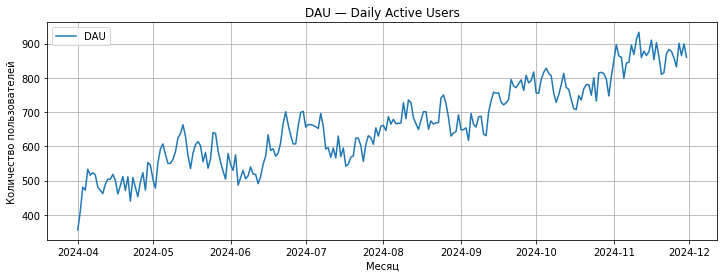

In [34]:
#Установим размер графика
plt.figure(figsize=(12, 4))

#Посмтроим линейный график
plt.plot(dau['day'], dau['DAU'], label='DAU')
plt.title('DAU — Daily Active Users')
plt.xlabel('Месяц')
plt.ylabel('Количество пользователей')
plt.legend()
plt.grid()
plt.show()

Динамика DAU за рассматриваемые период положительная. Количество активных пользователей в день постоянно растет и середине ноября превышает более 900 пользователей в день, когда в начале апреля было 356 пользователей.

Рассчитаем динамику MAU и визуализируем в виде линейного графика.
Для этого выделим отдельно столбец с месяцем посещения и сгруппируем уникальных пользователей по месяцу посещения.

In [35]:
#Создаем столбец с месяцем посещения
visits['month'] = visits['session_start'].dt.to_period('M').astype('str')

In [36]:
#Рассчитем количество уникальных пользователей по месяцам
mau = visits.groupby('month')['user_id'].nunique().reset_index(name = 'MAU')

In [37]:
#Проверим получившиеся даненые MAU
mau

,month,MAU
0,2024-04,9069
1,2024-05,10849
2,2024-06,10240
3,2024-07,10864
4,2024-08,11977
5,2024-09,12089
6,2024-10,13036
7,2024-11,14097


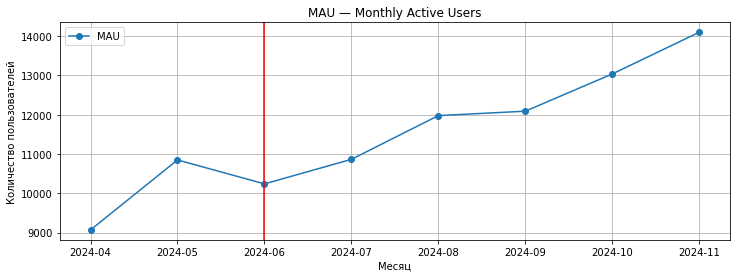

In [38]:
#Установим размер графика
plt.figure(figsize=(12, 4))

#Построим линейный график
plt.plot(mau['month'], mau['MAU'], label='MAU', marker='o')
plt.title('MAU — Monthly Active Users')
plt.xlabel('Месяц')
plt.ylabel('Количество пользователей')
plt.legend()
plt.axvline(x =('2024-06'), color='red') #Добавлена линия когда в приложении появился новый контент
plt.grid()
plt.show()

Динамика MAU положительная за рассматриваемый период. Стоит отметить, что MAU незначительно упал к началу лета. С появлением в приложении нового спортивного контента метрика начала расти и к концу рассматриваемого периода выросла до 14000 пользователей с 9000 пользователей в апреле 2024.

Для расчета Stickiness ("коэффициента липкости") необходимо будет рассчитать средний DAU в месяц и разделить на MAU. 

Добавим в датасет `dau` столбец с месяцем `month` и рассчитаем средний DAU за месяц. Сохраним средний DAU в переменной `avg_dau`.

In [39]:
#Выделяем месяц в датасете dau
dau['month'] = pd.to_datetime(dau['day']).dt.to_period('M').astype(str)

In [40]:
#Считаем средний DAU по месяцам
dau_avg = dau.groupby('month')['DAU'].mean().reset_index(name = 'avg_dau')
dau_avg

,month,avg_dau
0,2024-04,488.333333
1,2024-05,576.967742
2,2024-06,580.366667
3,2024-07,615.000000
4,2024-08,681.193548
5,2024-09,724.100000
6,2024-10,773.193548
7,2024-11,868.133333


In [41]:
#Объединим датасет mau и dau_avg в датасете для расчета Stickiness
stickiness_table = mau.merge(dau_avg, on = 'month', how = 'left')

In [42]:
#Рассчитаем Stickiness в %
stickiness_table['Stickiness'] = 100* (stickiness_table['avg_dau'] / stickiness_table['MAU'])

In [43]:
#Проверим полученные данные
stickiness_table

,month,MAU,avg_dau,Stickiness
0,2024-04,9069,488.333333,5.384644
1,2024-05,10849,576.967742,5.318165
2,2024-06,10240,580.366667,5.667643
3,2024-07,10864,615.000000,5.660898
4,2024-08,11977,681.193548,5.687514
5,2024-09,12089,724.100000,5.989743
6,2024-10,13036,773.193548,5.931218
7,2024-11,14097,868.133333,6.158284


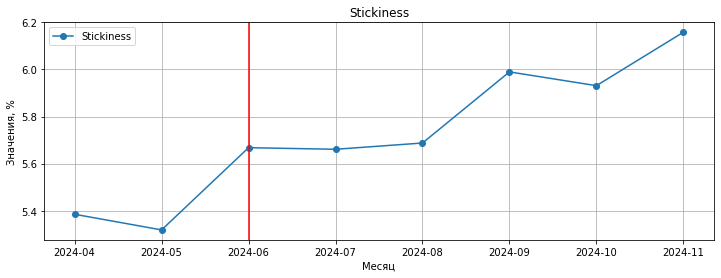

In [44]:
#Установим размер графика
plt.figure(figsize=(12, 4))

#Создадим линейный график
plt.plot(stickiness_table['month'], stickiness_table['Stickiness'], label='Stickiness', marker='o')
plt.title('Stickiness')
plt.xlabel('Месяц')
plt.ylabel('Значения, %')
plt.legend()
plt.axvline(x =('2024-06'), color='red') #Добавлена линия когда в приложении появился новый контент
plt.grid()
plt.show()

Stickiness показывает положительную динамику после добавленя нового контента. В течение летних месяцев коэффициент имеет небольшой рост, что может быть связано с сезонной активностью пользователей, но с сентября показывает значительный прирост до 6% и до 6,2% в ноябре.

### Задача 2

В разрезе каждого месяца привлечения новых пользователей рассчитаем:
- Среднюю стоимость привлечения пользователя (CAC)
- LTV и ROI с учетом покупок, совершенных за 28 дней с момента привлечения.

Анализ будем проводить на основе датасета `profiles`, в котором разделим пользователей на когорты по месяцам и сохраним названия когорт в столбце `cohort`.

In [45]:
#Выделяем когорты по первому месяцу привлечения
profiles['cohort'] = pd.to_datetime(profiles['first_dt']).dt.to_period('M')
#Проверим полученные данные
profiles.head()

,user_id,first_dt,first_channel,cac,cohort
0,26034876,2024-05-29,FaceBoom,0.953250,2024-05
1,69890364,2024-06-28,RocketSuperAds,0.604917,2024-06
2,75610104,2024-06-09,FaceBoom,1.196159,2024-06
3,76692397,2024-10-21,FaceBoom,1.147967,2024-10
4,80224421,2024-06-21,FaceBoom,1.208981,2024-06


Посчитаем среднюю стоимость привлечения пользователей в каждой когорте.

In [46]:
#Сгруппируем пользователей по когортам и рассчитаем средний CAC
cohort_cac = profiles.groupby('cohort')['cac'].mean().reset_index(name='avg_cac')
cohort_cac

,cohort,avg_cac
0,2024-04,0.734706
1,2024-05,0.748572
2,2024-06,0.973978
3,2024-07,1.054344
4,2024-08,1.155601
5,2024-09,1.178301
6,2024-10,1.323047
7,2024-11,1.320148


Для расчета LTV и ROI создадим датасет с данными о пользователях и покупках, которые были совершены за 28 дней с момента привлечения, сохраним данные в датасет `orders_28days`. Так как события пользователей могли быть совершены в ноябре и не могут до 30.11 пройти 28-дневный лайфтайм, то такие события мы ограничим через значение `cutoff_date`. От последнего дня анализа событий отнимем значение в 28 дней, это и будет крайний день покупок пользователей для анализа.

In [47]:
#Считаем день ограничения анализа данных
cutoff_date = pd.to_datetime('2024-11-30') - pd.Timedelta(days=28)

In [48]:
#Ограничим выборку покупок пользователей полученной датой cutoff_date
orders_filtered = orders[
    orders['first_dt'] <= cutoff_date].copy()

In [49]:
#Создадим датасет с пользователемя с 28 дней лайфтайма
orders_28days = orders_filtered[orders_filtered['lifetime'] <= 28].copy()

In [50]:
#Добавим когорты к датасету покупок за 28 дней
orders_28days['cohort'] = pd.to_datetime(orders_28days['first_dt']).dt.to_period('M')
#Проверим полученные данные
orders_28days.head()

,user_id,event_dt,revenue,first_dt,first_channel,lifetime,cohort
0,771951256319,2024-04-01 05:56:26,2.99,2024-04-01,FaceBoom,1,2024-04
1,829942381059,2024-04-01 14:55:02,2.99,2024-04-01,FaceBoom,1,2024-04
2,727879856738,2024-04-01 22:15:09,14.99,2024-04-01,FaceBoom,1,2024-04
3,481270888930,2024-04-01 06:05:14,2.99,2024-04-01,TipTop,1,2024-04
4,844695029762,2024-04-01 01:19:52,2.99,2024-04-01,FaceBoom,1,2024-04


Посчитаем общее количество пользователей в когортах в датасете `profiles` и общую сумму выручки в датасете `orders_28days`.

In [51]:
#Посчитаем суммарную выручку
cohort_rev = orders_28days.groupby('cohort').agg(
    total_revenue=('revenue', 'sum')).reset_index()

In [52]:
#Проверим полученные данные
cohort_rev.head()

,cohort,total_revenue
0,2024-04,7425.63
1,2024-05,8141.76
2,2024-06,7447.84
3,2024-07,9991.41
4,2024-08,10367.05


In [53]:
#Посчитаем количество пользователей в когортах, учитывая платящих и неплатящих пользователей
cohort_users = profiles.groupby('cohort')['user_id'].count().reset_index(name = 'total_users')

In [54]:
#Проверим полученные данные
cohort_users.head()

,cohort,total_users
0,2024-04,9069
1,2024-05,9789
2,2024-06,8719
3,2024-07,8742
4,2024-08,9518


In [55]:
#Объединим данные о выручке и количестве пользователей
cohort_df = cohort_rev.merge(cohort_users, on = 'cohort', how = 'left')

In [56]:
#Посчитаем LTV
cohort_df['ltv'] = cohort_df['total_revenue'] / cohort_df['total_users']

In [57]:
#Проверим полученные данные
cohort_df

,cohort,total_revenue,total_users,ltv
0,2024-04,7425.63,9069,0.818793
1,2024-05,8141.76,9789,0.831725
2,2024-06,7447.84,8719,0.854208
3,2024-07,9991.41,8742,1.142920
4,2024-08,10367.05,9518,1.089205
5,2024-09,10085.88,9198,1.096530
6,2024-10,11449.71,9520,1.202701
7,2024-11,860.35,10301,0.083521


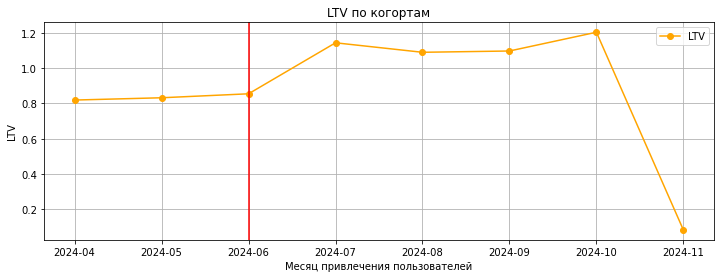

In [58]:
#Установим размер графика
plt.figure(figsize=(12, 4))

#Построим линейный график LTV
plt.plot(cohort_df['cohort'].astype(str), cohort_df['ltv'], label='LTV', marker = 'o', color = 'orange')
plt.title('LTV по когортам')
plt.xlabel('Месяц привлечения пользователей')
plt.ylabel('LTV')
plt.axvline(x =('2024-06'), color='red')  #Пометим дату добавления нового контента
plt.legend()
plt.grid()
plt.show()

LTV пользователей вырос после добавления спортивного контента, начиная с июня. В течение года показатель был высоким. Снижение LTV с октября по ноябрь связано с рассматриваемым периодом анализа. В ноябре не все пользователи имели 28 дневный лафйтайм.

Проведем анализ CAC по когортам.

In [59]:
#Посчитаем количество пользователей и суммарные затраты на их привлечение по когортам
cohort_cac = profiles.groupby('cohort').agg(
    total_cac=('cac', 'sum'),
    unique_users=('user_id', 'nunique')
).reset_index()

# Рассчитываем средний CAC
cohort_cac['cac'] = cohort_cac['total_cac'] / cohort_cac['unique_users']

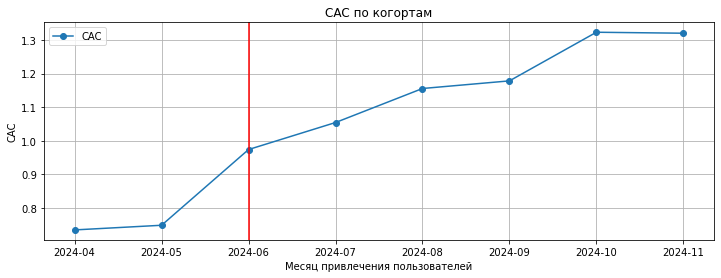

In [60]:
#Установим размер графика
plt.figure(figsize=(12, 4))

#Построим линейный график CAC
plt.plot(cohort_cac['cohort'].astype(str), cohort_cac['cac'], label='CAC', marker = 'o')
plt.title('CAC по когортам')
plt.xlabel('Месяц привлечения пользователей')
plt.ylabel('CAC')
plt.axvline(x =('2024-06'), color='red') #Пометим дату добавления нового контента
plt.legend()
plt.grid()
plt.show()

В с апреля по ноябрь 2024 года наблюдается увеличение CAC. С начала лета САС начал расти, что как раз совпадает с добавлением нового контента, увеличением затрат на привлечение новых пользователей.

In [61]:
#Объединяем данные CAC и LTV
cohorts = pd.merge(cohort_df, cohort_cac, on='cohort', suffixes=('_ltv', '_cac'))

#Рассчитываем ROI
cohorts['roi'] = (cohorts['total_revenue'] - cohorts['total_cac']) / cohorts['total_cac'] * 100

In [62]:
#Проверим полученные данные
cohorts

,cohort,total_revenue,total_users,ltv,total_cac,unique_users,cac,roi
0,2024-04,7425.63,9069,0.818793,6663.052333,9069,0.734706,11.444870
1,2024-05,8141.76,9789,0.831725,7327.775412,9789,0.748572,11.108209
2,2024-06,7447.84,8719,0.854208,8492.116887,8719,0.973978,-12.297015
3,2024-07,9991.41,8742,1.142920,9217.078561,8742,1.054344,8.401051
4,2024-08,10367.05,9518,1.089205,10999.013650,9518,1.155601,-5.745639
5,2024-09,10085.88,9198,1.096530,10838.014747,9198,1.178301,-6.939783
6,2024-10,11449.71,9520,1.202701,12595.403113,9520,1.323047,-9.096121
7,2024-11,860.35,10301,0.083521,13598.849128,10301,1.320148,-93.673362


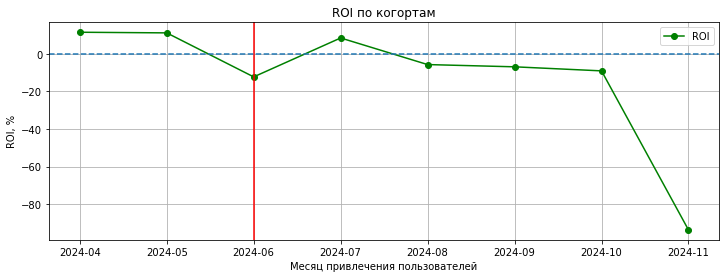

In [63]:
#Установим размер графика
plt.figure(figsize=(12, 4))

#Построим линейный график ROI
plt.plot(cohorts['cohort'].astype(str), cohorts['roi'], label='ROI', marker='o', color = 'green')
plt.axvline(x =('2024-06'), color='red') #Пометим дату добавления нового контента
plt.axhline(y=0, linestyle='--') #Уровень окупаемости
plt.title('ROI по когортам')
plt.xlabel('Месяц привлечения пользователей')
plt.ylabel('ROI, %')
plt.legend()
plt.grid()
plt.show()

Окупаемость инвестиций падает с июля по ноябрь. До добавления нового контента окупаемость также падала, затем в с июня по июль окупаемость немного стабилизировалась. Но к концу года показатель ROI снова падает, что также указывает на необходимость улучшения маркетинговой стратегии.

Из-за увеличения CAC и падением LTV окупаемость инвестиций падает в течение года. Необходимо детальнее рассмотреть маркетинговые стратегии и источники привлечения пользователей и провести их оптимизацию.

## Анализ метрик в разрезе источника привлечения


### Задача 1

Разберем подробнее метрики в разрезе источников привлечения.

Определим самые популярные источники привлечения. Для этого:
- посчитаем общее число привлеченных пользователей для каждого источника
- визуализируем динамику наборы новых пользователей по дням в каждом источнике.
- рассчитаем и визуализируем динамику DAU, MAU и Stickiness по источникам привлечения.

In [64]:
#Посчитаем общее количество привлеченных пользователей для каждого источника
channel_users = profiles['first_channel'].value_counts().reset_index()
channel_users.columns = ['channel', 'new_users']
#Проверим полученные данные
channel_users

,channel,new_users
0,FaceBoom,28401
1,TipTop,18118
2,RocketSuperAds,14257
3,MediaTornado,14080


Больше всего пользователей было привлечено через источник FaceBoom (28401), меньше всего через MediaTornado(14080).

In [65]:
#Посчитаем количество новых пользователей по дням в каждом источнике привлечения
daily_users_by_channel = (
    profiles.groupby(['first_channel', 'first_dt'])['user_id']
    .nunique()
    .reset_index(name='new_users')
)

In [66]:
#Проверим получившиеся данные
daily_users_by_channel.head()

,first_channel,first_dt,new_users
0,FaceBoom,2024-04-01,133
1,FaceBoom,2024-04-02,94
2,FaceBoom,2024-04-03,133
3,FaceBoom,2024-04-04,105
4,FaceBoom,2024-04-05,110


Подробнее количество новых пользователей по дням через каждый источник привлечения можно будет увидеть на графике.

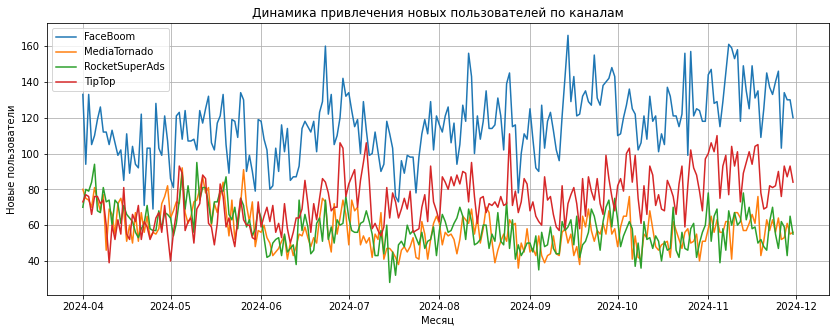

In [67]:
#Установим размер графика
plt.figure(figsize=(14, 5))

#Цикл для построения графика по каналм привлечения
for ch in daily_users_by_channel['first_channel'].unique():
    df_plot = daily_users_by_channel[daily_users_by_channel['first_channel'] == ch]
    plt.plot(df_plot['first_dt'], df_plot['new_users'], label=ch)
    

plt.title('Динамика привлечения новых пользователей по каналам')
plt.xlabel('Месяц')
plt.ylabel('Новые пользователи')
plt.legend()
plt.grid()
plt.show()

Больше всего новых пользователей привлекает канал FaceBoom, его дневные показатели почти не опускаются ниже 80 пользователей в день.
Меньше всего пользователей привлекает канал RocketSuperAds, от 80 до 40 пользователей в день.

In [68]:
#Посчитаем количество активных пользователей в день по каналам привлечения
dau_by_channel = visits.groupby(['day' ,'first_channel'])['user_id'].nunique().reset_index(name='DAU')
#Проверим получившиеся данные
dau_by_channel.head()

,day,first_channel,DAU
0,2024-04-01,FaceBoom,133
1,2024-04-01,MediaTornado,80
2,2024-04-01,RocketSuperAds,70
3,2024-04-01,TipTop,73
4,2024-04-02,FaceBoom,113


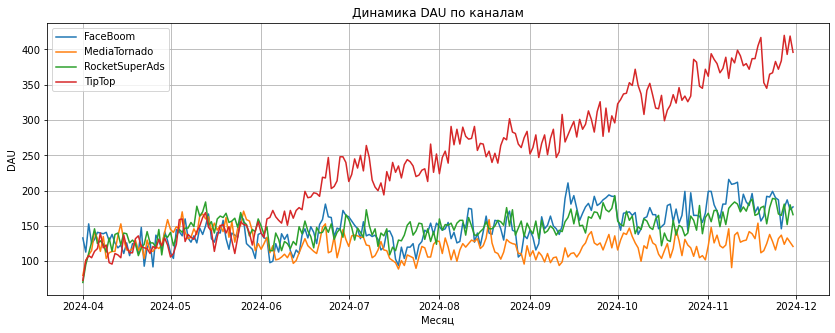

In [69]:
#Установим размер графика
plt.figure(figsize=(14, 5))

#Цикл для построения графика по источникам привлечения
for ch in dau_by_channel ['first_channel'].unique():
    df_plot = dau_by_channel[dau_by_channel['first_channel'] == ch]
    plt.plot(df_plot['day'], df_plot['DAU'], label=ch)

plt.title('Динамика DAU по каналам')
plt.xlabel('Месяц')
plt.ylabel('DAU')
plt.legend()
plt.grid()
plt.show()

В разрезе источников привлечения больше всего активных пользователей за рассматриваемый период у TipTop. Аудитория активных пользователей постоянно растет в течение года. Особенно активный рост можно заметить после июня, когда был добавлен новый контент.

Через источник FaceBoom рост активных пользователей также есть, но небольшой, около 50-100 пользователей в месяц.

Источники MediaTornado и RocketSuperAds немного увеличили активную аудиторию после добавления нового контента, но незначительно, как TipTop.

In [70]:
#Рассчитаем MAU по источникам привлечения
mau_by_channel = visits.groupby(['month', 'first_channel'])['user_id'].nunique().reset_index(name='MAU')
#Проверим полученные данные
mau_by_channel.head()

,month,first_channel,MAU
0,2024-04,FaceBoom,3170
1,2024-04,MediaTornado,1969
2,2024-04,RocketSuperAds,2030
3,2024-04,TipTop,1900
4,2024-05,FaceBoom,3521


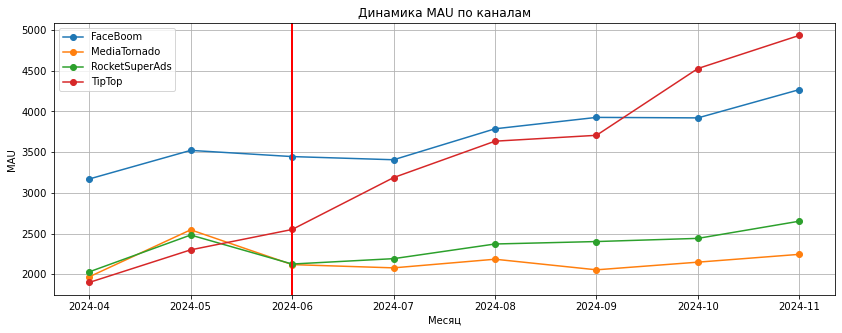

In [71]:
#Установим размер графика
plt.figure(figsize=(14, 5))

#Цикл для построения графика по источникам привлечения
for ch in mau_by_channel ['first_channel'].unique():
    df_plot = mau_by_channel[mau_by_channel['first_channel'] == ch]
    plt.plot(df_plot['month'], df_plot['MAU'], label=ch, marker = 'o')
    plt.axvline(x =('2024-06'), color='red') #Пометим дату добавления нового контента

plt.title('Динамика MAU по каналам')
plt.xlabel('Месяц')
plt.ylabel('MAU')
plt.legend()
plt.grid()
plt.show()

На графиках с динамикой MAU по источникам привлечения виден также рост аудитории у TipTop и FaceBoom. У RocketSuperAds и MediaTornado рост аудитории небольшой. После июня снизился, но стабилизировался к осени.

Посчитаем "коэффициент липкости" Stickiness по источникам привлечения.

In [72]:
#Добавляяем месяц в датасет с DAU для дальнейшего объединения
dau_by_channel['month'] = pd.to_datetime(dau['day']).dt.to_period('M').astype(str)

In [73]:
#Посчитаем средний DAU по источникам привлечения
dau_by_channel_avg = dau_by_channel.groupby(['first_channel','month'])['DAU'].mean().reset_index(name = 'avg_dau')
dau_by_channel_avg.head()

,first_channel,month,avg_dau
0,FaceBoom,2024-04,134.375000
1,FaceBoom,2024-05,126.625000
2,FaceBoom,2024-06,118.571429
3,FaceBoom,2024-07,123.375000
4,FaceBoom,2024-08,135.375000


In [74]:
#Объединим данные по среднему DAU и MAU по источникам привлечения
stickness_by_channel = mau_by_channel.merge(dau_by_channel_avg, on = ['first_channel','month'], how = 'left')
#Посчитаем Stickiness по источникам привлечения
stickness_by_channel['Stickness'] = 100* (stickness_by_channel['avg_dau'] / stickness_by_channel['MAU'])
#Проверим получившиеся данные
stickness_by_channel.head()

,month,first_channel,MAU,avg_dau,Stickness
0,2024-04,FaceBoom,3170,134.375000,4.238959
1,2024-04,MediaTornado,1969,116.000000,5.891315
2,2024-04,RocketSuperAds,2030,114.714286,5.650950
3,2024-04,TipTop,1900,108.428571,5.706767
4,2024-05,FaceBoom,3521,126.625000,3.596279


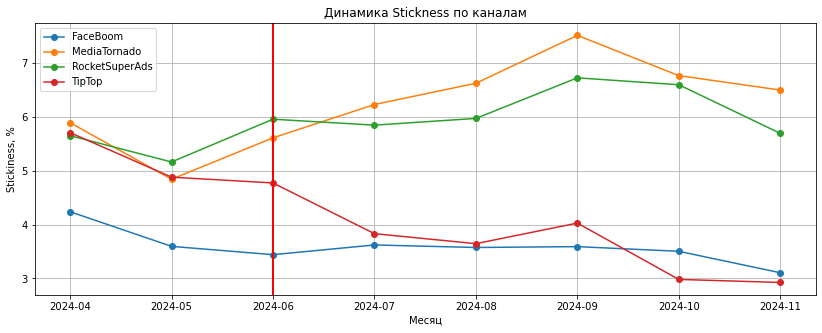

In [75]:
#Установим размер графика
plt.figure(figsize=(14, 5))

#Цикл для построения графика по источникам привлечения
for ch in stickness_by_channel ['first_channel'].unique():
    df_plot = stickness_by_channel[stickness_by_channel['first_channel'] == ch]
    plt.plot(df_plot['month'], df_plot['Stickness'], label=ch, marker = 'o')
    plt.axvline(x =('2024-06'), color='red') #Пометим дату добавления нового контента

plt.title('Динамика Stickness по каналам')
plt.xlabel('Месяц')
plt.ylabel('Stickiness, %')
plt.legend()
plt.grid()
plt.show()

Проанализировав динамику DAU, MAU и Stickiness по источникам привлечения, можно сделать вывод, что добавление спортивного контента положительно повлияло на рост аудитории для TipTop и FaceBoom, но не принесло такого же эффекта для MediaTornado и RocketSuperAds.

Но Stickiness у каналов MediaTornado и RocketSuperAds вырос, что может указывать на то, что новый контент удержал существующих пользователей, но не привлек новых через эти каналы.

Падение Stickiness у каналов FaceBoom и TipTop вызвано тем, что через эти каналы привлечено много новых пользователей, но удержать их и конвертировать в постоянных пользователей не удалось.

### Задача 2

Рассмотрим динамику изменения метрик на 28-й день в разрезе источника привлечения.
Для этого проведем анализ с выделением недельных когорт по дате привлечения и рассчитаем:
- скользящее удержание на 14-й день с момента привлечения (за период с 14-го по 28-й день)
- конверсию в покупку
- недельную динамику затрат на маркетинг по каждому источнику привлечения
- динамику среднего CAC, значения LTV и ROI.

По результатам проведеного анализа рекламных каналов необходимо будет выяснить какие рекламные каналы не вышли на уровень окупаемости за ожидаемый период.

In [76]:
#Добавим в датасеты profiles, orders и visits когорты по неделям
profiles['cohort_week'] = pd.to_datetime(profiles['first_dt']).dt.to_period('W').apply(lambda r: r.start_time)
orders_28days['cohort_week'] = pd.to_datetime(orders['first_dt']).dt.to_period('W').apply(lambda r: r.start_time)
visits['cohort_week'] = pd.to_datetime(visits['first_dt']).dt.to_period('W').apply(lambda r: r.start_time)

In [77]:
#Фильтруем датасет visits до даты с 28-дневным лайфтаймом
visits_filtered = visits[
    visits['first_dt'] <= cutoff_date].copy()

In [78]:
#Оставляем в датасете только пользователей с lifetime 28 дней
visits_28 = visits[visits['lifetime']<=28].copy()

In [79]:
#Считаем количество пользователей в когортах
cohort_week_users = profiles.groupby(['cohort_week', 'first_channel'])['user_id'].nunique().reset_index(name = 'total_users')
#Проверяем полученные данные
cohort_week_users.head()

,cohort_week,first_channel,total_users
0,2024-04-01,FaceBoom,820
1,2024-04-01,MediaTornado,522
2,2024-04-01,RocketSuperAds,542
3,2024-04-01,TipTop,516
4,2024-04-08,FaceBoom,749


Проведем расчет скользящего удержания пользователей за период 14-28 дней.

In [80]:
#Посчитаем удержанных пользователей на 14-28 день
retained_users = visits[
    (visits_28['lifetime'] >= 14) & #фильтруем от 14 дня
    (visits['lifetime'] <= 28)    #до 28 дня
].groupby(
    ['cohort_week', 'first_channel']
)['user_id'].nunique().reset_index(name='retained_14_28')

In [81]:
#Объединим данные
retention = pd.merge(
    cohort_week_users,
    retained_users,
    on=['cohort_week', 'first_channel'],
    how='left'
)

In [82]:
#Посчитаем Retention
retention['retention_rate'] = (
    retention['retained_14_28'] / 
    retention['total_users'] * 100
)

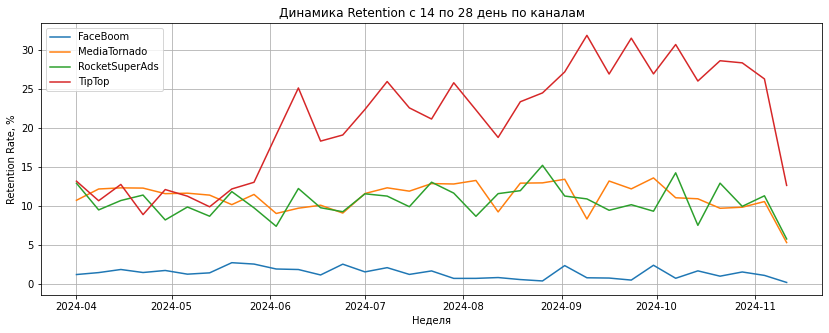

In [83]:
#Установим размер графика
plt.figure(figsize=(14, 5))

#Цикл для построения графика по источникам привлечения
for ch in retention['first_channel'].unique():
    df_plot = retention[retention['first_channel'] == ch]
    plt.plot(df_plot['cohort_week'], df_plot['retention_rate'], label=ch)

plt.title('Динамика Retention c 14 по 28 день по каналам')
plt.xlabel('Неделя')
plt.ylabel('Retention Rate, %')
plt.legend()
plt.grid()
plt.show()

**FaceBoom** уровень удержания оставался стабильным на протяжении всего периода, новый контент никак не повлиял на показатели.<br>**MediaTornado** и **RocketSuperAds** После добавления спортивного контента наблюдается незначительный рост, но в целом уровень удержания стабильный.<br> **TipTop** Уровень Retention показывает значительный рост, спортивный контент принес большее число заинтересованных пользователей из этого источника.

Посчитаем конверсию в покупку. Для этого добавим в датасет `profiles` признак платящего пользователя.

In [84]:
#Добавляем признак платящего пользователя
profiles['is_payer_user'] = profiles['user_id'].isin(orders_28days['user_id'].unique())

In [85]:
##Посчитаем конверсию в покупку
cr_data = profiles.groupby(['cohort_week', 'first_channel'])['is_payer_user'].mean().reset_index(name = 'cr_rate')

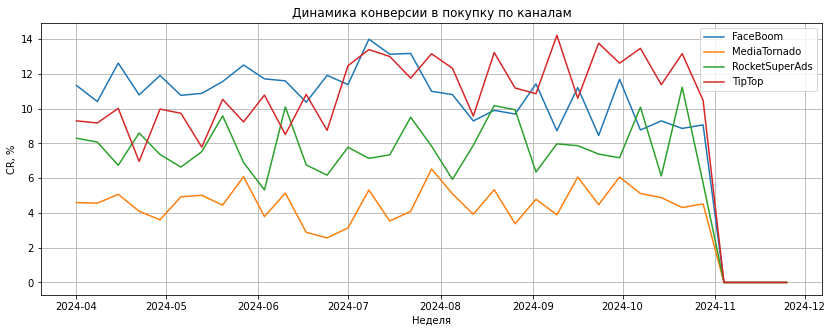

In [86]:
#Установим размер графика
plt.figure(figsize=(14, 5))

#Цикл для построения графика по источникам привлечения
for ch in cr_data['first_channel'].unique():
    df_plot = cr_data[cr_data['first_channel'] == ch]
    plt.plot(df_plot['cohort_week'], df_plot['cr_rate'] * 100, label=ch)

plt.title('Динамика конверсии в покупку по каналам')
plt.xlabel('Неделя')
plt.ylabel('CR, %')
plt.legend()
plt.grid()
plt.show()

Пользователи канала **TipTop** и **FaceBoom** после добавления спортивного контента стали чаще совершать покупки в приложении.

Пользователи канала **RocketSuperAds** и **MediaTornado** не монетизированы, они не совершают за время анализа больше покупок, чтобы конверсия выросла, она остается стабильной.

В ноябре уонверсия в покупку имеет резкое снижение из-за периода анализа. Рассмотрены только пользователи с 28 днями lifetime.

Проведем анализ динамики недельных затрат на маркетинг по каналам.

In [87]:
#Выделим недели в датах затрат на маркетинг
costs['week'] = pd.to_datetime(costs['dt']).dt.to_period('W').apply(lambda r: r.start_time)

In [88]:
#Посчитаем сумму недельных затрат по каналам
weekly_costs = costs.groupby(['week', 'channel'])['costs'].sum().reset_index()

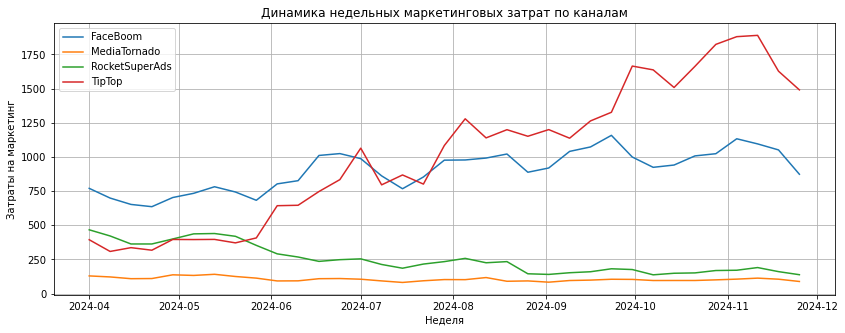

In [89]:
#Установим размер графика
plt.figure(figsize=(14, 5))

#Цикл для построения графика по источникам привлечения
for ch in weekly_costs['channel'].unique():
    df_plot = weekly_costs[weekly_costs['channel'] == ch]
    plt.plot(df_plot['week'], df_plot['costs'], label=ch)

plt.title('Динамика недельных маркетинговых затрат по каналам')
plt.xlabel('Неделя')
plt.ylabel('Затраты на маркетинг')
plt.legend()
plt.grid()
plt.show()

Маркетинговые затраты канала TipTop росли с каждой неделей и помогли привлечь больше новых и активных пользователей в приложение. Затраты на RocketSuperAds после июня были немного снижены. Среди остальных каналов у FaceBoom самые высокие затраты в течение года, за исключением TipTop.

In [90]:
#Посчитаем средний CAC в неделю по каналам
avg_cac = profiles.groupby(['cohort_week', 'first_channel'])['cac'].mean().reset_index(name = 'avg_cac')

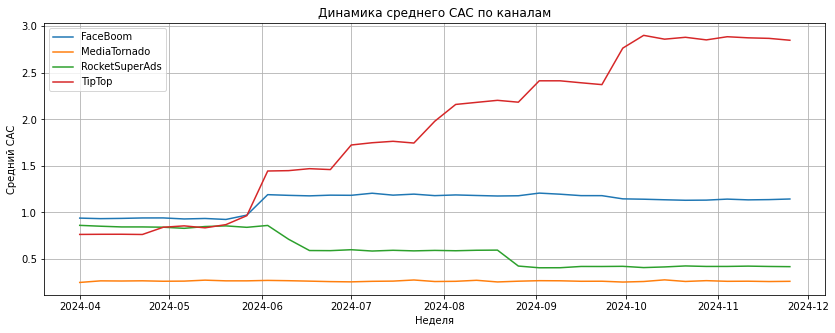

In [91]:
#Установим размер графика
plt.figure(figsize=(14, 5))

#Цикл для построения графика по источникам привлечения
for ch in avg_cac['first_channel'].unique():
    df_plot = avg_cac[avg_cac['first_channel'] == ch]
    plt.plot(df_plot['cohort_week'], df_plot['avg_cac'], label=ch)

plt.title('Динамика среднего CAC по каналам')
plt.xlabel('Неделя')
plt.ylabel('Средний CAC')
plt.legend()
plt.grid()
plt.show()

Графики динамики среднего CAC отражает также как и график суммарных затрат, что средний CAC у **TipTop** вырос после добавления нового спортивного контента. Маркетинговые затраты были скорректированы, с учетом того, что у **RocketSuperAds** бюджет уменьшен и перенаправлен на **TipTop**.

Для анализа LTV и ROI посчитаем суммарную выручку пользователей с 28 днями жизни, затем объединим с данными по количеству пользователей в когортах `cohort_week_users`.

In [92]:
#Считаем суммарную выручку
sum_rev = orders_28days.groupby(['first_channel', 'cohort_week'])['revenue'].sum().reset_index()

In [93]:
#Объединяем данные с количеством пользователей в когортах
ltv_cohort = sum_rev.merge(cohort_week_users, on = ['cohort_week', 'first_channel'], how = 'left')

In [94]:
#Считаем LTV
ltv_cohort['ltv'] = ltv_cohort['revenue']/ltv_cohort['total_users']

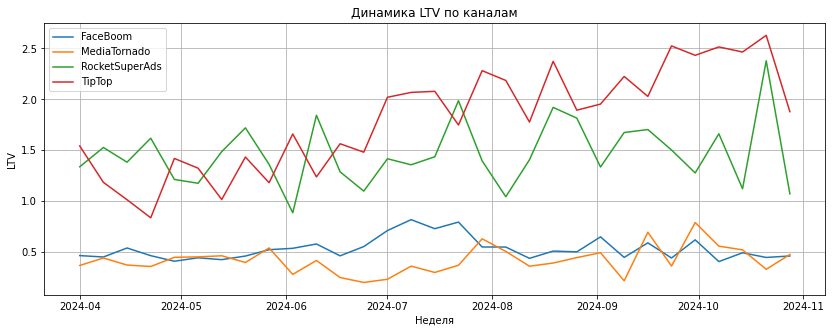

In [95]:
#Установим размер графика
plt.figure(figsize=(14, 5))

#Цикл для построения графика по источникам привлечения
for ch in ltv_cohort['first_channel'].unique():
    df_plot = ltv_cohort[ltv_cohort['first_channel'] == ch]
    plt.plot(df_plot['cohort_week'], df_plot['ltv'], label=ch)
    
plt.title('Динамика LTV по каналам')
plt.xlabel('Неделя')
plt.ylabel('LTV')
plt.legend()
plt.grid()
plt.show()

Пользователи, привлеченные через **TipTop** и **RocketSuperAds** показывают лучшую динамику LTV за период. LTV пользователей TipTop начинает расти после спортивного контента.

Несмотря на то, что у **RocketSuperAds** CAC был снижен, пользователи все равно приносили стабильный LTV в течение года.

In [96]:
#Объединим данные по LTV и среднему CAC когорт
metrics = ltv_cohort.merge(avg_cac, on = (['cohort_week', 'first_channel']), how = 'left')

In [97]:
#Посчитаем ROI
metrics['roi'] = (metrics['ltv'] - metrics['avg_cac'])/metrics['avg_cac']

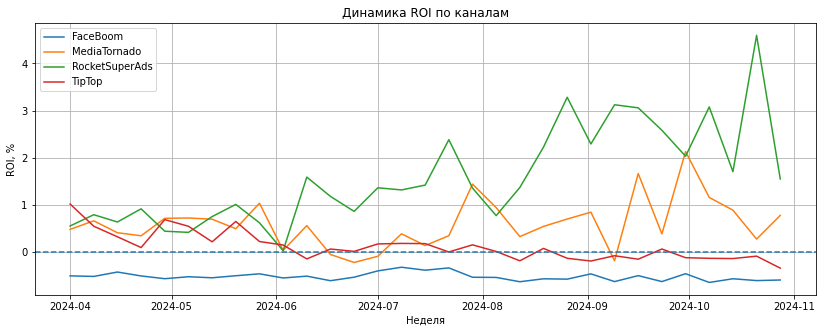

In [98]:
#Установим размер графика
plt.figure(figsize=(14, 5))

#Цикл для построения графика по источникам привлечения
for ch in metrics['first_channel'].unique():
    df_plot = metrics[metrics['first_channel'] == ch]
    plt.plot(df_plot['cohort_week'], df_plot['roi'], label=ch)

plt.axhline(y=0, linestyle='--') #Уровень окупаемости
plt.title('Динамика ROI по каналам')
plt.xlabel('Неделя')
plt.ylabel('ROI, %')
plt.legend()
plt.grid()
plt.show()

**RocketSuperAds** демонстрирует наибольший потенциал для роста, в то время как **MediaTornado** требует анализа причин нестабильности. **FaceBoom** остается стабильно неокупаемым и может быть оптимизирован для увеличения ROI. **TipTop** нуждается в корректировке стратегии для улучшения результатов.

## Анализ периода окупаемости маркетинговых вложений

Для FaceBoom и TipTop рассчитаем и визуализируем в виде тепловой карты значения ROI за период 8 недель.

Для этого разделим данные на недельные когорты по дате привлечения `first_week`, в качестве интервала наблюдения будем использовать недельный лайфтайм пользователей `N_week`.

In [99]:
#Добавим в датасет orders неделю, когда совершали заказ
orders['order_week'] = orders['event_dt'].dt.to_period('W').dt.to_timestamp()
#Добавим в датасет orders неделю первого привлечения
orders['cohort_week'] = orders['first_dt'].dt.to_period('W').dt.to_timestamp()
#Посчитаем недельный лайфтайм между заказами и первым привлечением
orders['N_week'] = (orders['order_week'] - orders['cohort_week']).dt.days / 7

In [100]:
#Отфильтруем датасет orders по рассматриваемым каналам и недельным лайфтаймом в 8 недель
df_orders = orders[(orders['first_channel'].isin(['FaceBoom', 'TipTop'])) & 
                        (orders['N_week'] <= 8)]

In [101]:
#Отфильтруем датасет profiles по рассматриваемым каналам
profiles_filtered = profiles[profiles['first_channel'].isin(['FaceBoom', 'TipTop'])]

Посчитаем накопленную выручку по каждой когорте и неделе жизни пользователей.

In [102]:
df_orders.head()

,user_id,event_dt,revenue,first_dt,first_channel,lifetime,order_week,cohort_week,N_week
0,771951256319,2024-04-01 05:56:26,2.99,2024-04-01,FaceBoom,1,2024-04-01,2024-04-01,0.0
1,829942381059,2024-04-01 14:55:02,2.99,2024-04-01,FaceBoom,1,2024-04-01,2024-04-01,0.0
2,727879856738,2024-04-01 22:15:09,14.99,2024-04-01,FaceBoom,1,2024-04-01,2024-04-01,0.0
3,481270888930,2024-04-01 06:05:14,2.99,2024-04-01,TipTop,1,2024-04-01,2024-04-01,0.0
4,844695029762,2024-04-01 01:19:52,2.99,2024-04-01,FaceBoom,1,2024-04-01,2024-04-01,0.0


In [103]:
#Создаем мультииндекс для группировки
rev = df_orders.set_index(['first_channel', 'cohort_week', 'N_week'])

In [104]:
#Считаем сумму выручки по когортам
rev = rev.groupby(
    ['first_channel', 'cohort_week', 'N_week']
)['revenue'].sum()

In [105]:
# Вычисляем накопительную сумму внутри каждой когорты
rev = rev.groupby(
    level=['first_channel', 'cohort_week']
).cumsum().reset_index()

In [106]:
# Переименовываем столбец накопленной выручки
rev = rev.rename(columns={'revenue': 'cumulative_revenue'})

#Проверим полученные данные
rev.head()

,first_channel,cohort_week,N_week,cumulative_revenue
0,FaceBoom,2024-04-01,0.0,290.63
1,FaceBoom,2024-04-01,1.0,353.44
2,FaceBoom,2024-04-01,2.0,374.38
3,FaceBoom,2024-04-01,3.0,380.36
4,FaceBoom,2024-04-01,6.0,383.35


In [107]:
#Посчитаем когортный CAC
cac_costs = profiles.groupby(
    ['first_channel', 'cohort_week']
).agg(
    cac=('cac', 'mean'),  #Средний CAC по когорте
    total_users=('user_id', 'count'),  # Количество пользователей
).reset_index()

In [108]:
#Проверим полученные данные
cac_costs.head()

,first_channel,cohort_week,cac,total_users
0,FaceBoom,2024-04-01,0.938873,820
1,FaceBoom,2024-04-08,0.933074,749
2,FaceBoom,2024-04-15,0.935784,697
3,FaceBoom,2024-04-22,0.940509,676
4,FaceBoom,2024-04-29,0.940875,747


In [109]:
#Объединим данные с накопленным доходом и CAC
merged = rev.merge(cac_costs, on = ['first_channel', 'cohort_week'], how = 'left')

In [110]:
#Рассчитаем LTV когорт
merged['ltv'] = merged['cumulative_revenue']/merged['total_users']

In [111]:
#Рассчитаем ROI когорт
merged['roi'] = (merged['ltv'] - merged['cac'])/merged['cac']

In [112]:
#Проверим полученные данные
merged.head()

,first_channel,cohort_week,N_week,cumulative_revenue,cac,total_users,ltv,roi
0,FaceBoom,2024-04-01,0.0,290.63,0.938873,820,0.354427,-0.622498
1,FaceBoom,2024-04-01,1.0,353.44,0.938873,820,0.431024,-0.540913
2,FaceBoom,2024-04-01,2.0,374.38,0.938873,820,0.456561,-0.513714
3,FaceBoom,2024-04-01,3.0,380.36,0.938873,820,0.463854,-0.505946
4,FaceBoom,2024-04-01,6.0,383.35,0.938873,820,0.467500,-0.502063


In [113]:
#Приведем к строковому формату названия когорт
merged['cohort_week'] = merged['cohort_week'].astype('str')

In [114]:
#Отфильтруем данные только по каналу TipTop
merged_tiptop = merged[merged['first_channel']=='TipTop']

In [115]:
#Создаем сводную таблицу для канала TipTop
pivot_tiptop = merged_tiptop.pivot(index='cohort_week', columns='N_week', values='roi')

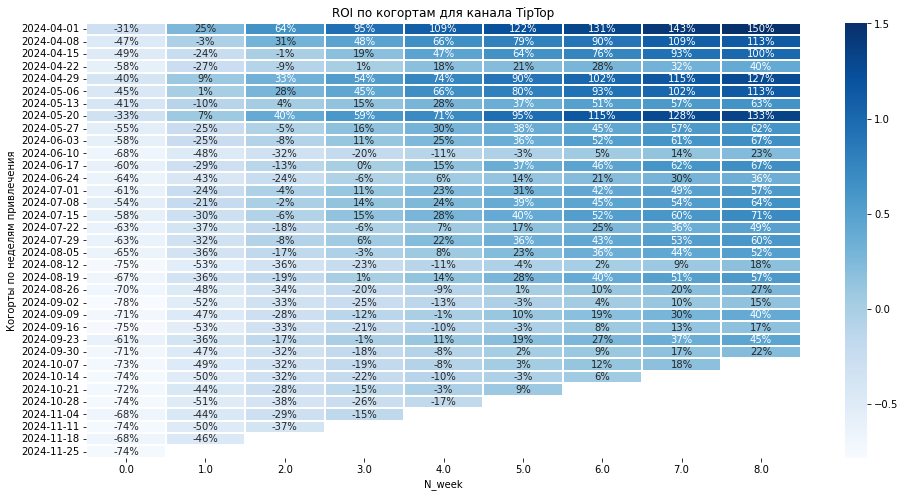

In [116]:
#Устанавливаем размер графика
plt.figure(figsize=(16, 8))

#Устанавливаем палитру
cmap = sns.color_palette("Blues", as_cmap=True)

#Посторим тепловую карту
sns.heatmap(pivot_tiptop,
          annot=True,
          cmap = cmap,  
          fmt='.0%',
          linewidths=2,
          annot_kws={"size": 10})


plt.title('ROI по когортам для канала TipTop')
plt.xlabel('N_week')
plt.ylabel('Когорты по неделям привлечения')
plt.show()

Анализ ROI показывает, что весной 2024 года канал TipTop привлекал наиболее окупаемых пользователй и окупамость быстро выходила на уровень 100% уже на 6-7 неделе. Когорты лета и далее до конца года окупаются медленее, к 8 неделям на уровень 100% окупаеость не вышла.

In [117]:
#Отфильтруем данные только по каналу FaceBoom
merged_faceboom= merged[merged['first_channel']=='FaceBoom']

In [118]:
#Создаем сводную таблицу для канала FaceBoom
pivot_faceboom = merged_faceboom.pivot(index='cohort_week', columns='N_week', values='roi')

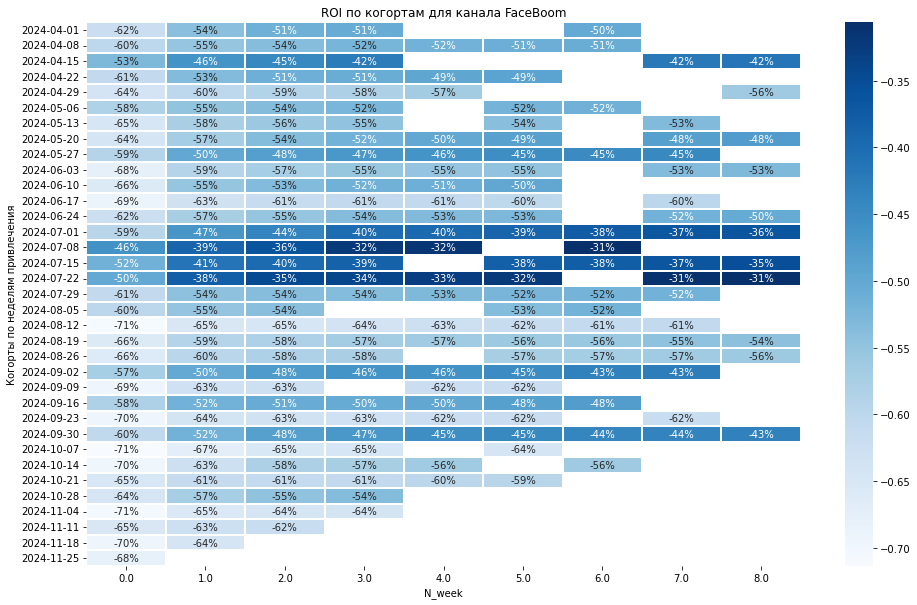

In [119]:
#Устанавливаем размер графика
plt.figure(figsize=(16, 10))

#Устанавливаем палитру
cmap = sns.color_palette("Blues", as_cmap=True)

#Посторим тепловую карту
sns.heatmap(pivot_faceboom,
          annot=True,
          cmap = cmap,  
          fmt='.0%',
          linewidths=2,
          annot_kws={"size": 10})


plt.title('ROI по когортам для канала FaceBoom')
plt.xlabel('N_week')
plt.ylabel('Когорты по неделям привлечения')
plt.show()

У канала FaсeBoom окупаемость не становится положительной на протяжении 8 недель. Необходимо расширить горизонт анализа для этого канала.

## Выводы и рекомендации

Был проведен анализ источников привлечения аудитории в приложение Procrastinate Pro+. Особое внимание было уделено основным продуктовым метрикам приложения с начала лета, так как был добавлен новый спортивный контент и к запуску нового контента была скорректирована маркетинговая стратегия привлечения пользователей. 

### **Общая динамика**
- количество активных пользователей выросло, с 365 до более 900 в день;
- MAU: увеличился с 9000 до 14000 пользователей
- Stickiness: вырос с 5.3% до 6.2%.

### **Распределение маркетинговых затрат по каналам привлечения**
- CAC: рост с 0.73 до 1.32 за период
- лидерами привлечения стали FaceBoom (8401 пользователь) и TipTop (18118 пользователей)
- низкие, но стабильные показатели привлечения: MediaTornado и RocketSuperAds (по ~14000 пользователей)

### **Анализов каналов привлечения**

**FaceBoom**<br>
`+` является крупнейшим истоничком привлечения<br>
`+` привлекает в среднем 80-150 пользователей в день<br>
`-` низкая конверсия в покупку<br>
`-` стабильное, но низкое и без роста удержание пользователей на 14-28 день<br>
`-` период окупаемости более 10 недель и высокий CAC.

**TipTop**<br>
`+` высокое удержание на 14-28 день<br>
`+` привлекает большое количество новых пользователей<br>
`+` положительно растущая коверсия в покупку<br>
`-` период окупаемости длительный, 8-10 недель<br>
`-` сезонное падение конверсии.

**RocketSuperAds и MediaTornado**<br>
`+` стабильно окупаемые каналы за период 28 дней<br>
`+` невысокий уровень стоимости привлечения пользователей CAC<br>
`+` высокий уровень `коэффициента липкости Stickiness`<br>
`-` низкие показатели привлечения и ограниченный охват<br>
`-` MAU и DAU почти не растут, особенно после добавления спортивного контента.

### Рекомендации

- перераспределить бюджет на каналы TipTop и RocketSuperAds, так как они показывают лучшие показатели удержания и конверсии
- оптимизировать расходы  и проанализировать рекламные креативы в FaceBoom и MediaTornado, так как у них высокий CAC и низкая конверсия
- для FaceBoom проанализировать аудиторию, провести ее сегментацию, чтобы улучшить удержание и монетизацию
- для TipTop провести анализ причин падения конверсии осенью, так как это может быть и сезонное снижение, и недостаток релевантного контента.

**Общие рекомендации для отдела маркетинга**
- добавить динамическое ценнобразование CAC для оптимизации затрат
- разработать программу лояльности для увеличения LTV
- провести исследование целевой аудитории и на его основании оптимизировать спортивный контент для разных каналов привлечения
- улучшить количество и качество контента, так как спустя полгода показатели Stickiness и Retention начали снижаться
- проработать программы лояльности для "холодных" пользователей в первые 14 дней дней.